## Train Neural Network Parameterisation

In this notebook we train a deterministic neural network parameterisation that learns a mapping from the resolved variables \(X\) to the subgrid-scale forcing \(U\).

- Inputs (`X`): coarse-resolution state of the one-layer Lorenz 1996 model at each time step.
- Targets (`U`): effective subgrid tendency diagnosed from the two-layer model in the previous notebook.

We:
- load the pre-computed training data generated by the two-layer L96 runs,
- split it into training and validation sets, 
- define a simple feed-forward neural network using PyTorch,
- optimise the network with mean-squared-error (MSE) loss, and
- (optionally) visualise the learned mapping from \(X\) to \(U\) offline.

The trained network will then be used in the next notebook as an online parameterisation inside the coarse-resolution L96 model.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader


from ml_models.TorchModels import  NN
from plotting_scripts.plot_data_histogram import plot_hist


In [2]:
# Random seed
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)

# Define dimensions of system (fixed)
K = 8   
J = 32  

# Define the parameters
h = 1
F = 20
c = 10
b = 10

# Define time-stepping
dt = 0.001        # Two layer (high-res) run at dt
dt_f = 0.005      # One layer (coarse-res) run at dt_f




In [3]:
# Data path should already exist as we have already run the notebook to generate training data
data_path = f'./outputs/'
# Get data
X = np.load(f'{data_path}/X_train_dtf.npy')
U = np.load(f'{data_path}/U_train_dtf.npy')
print(f'Data loaded from {data_path}')

print("X shape:", X.shape, "U shape:", U.shape)

# Optional: subsample in time to reduce temporal correlation between samples
subsample = 10  # adjust if you want more / fewer samples
X = X[::subsample]
U = U[::subsample]
print("After subsampling:", X.shape, U.shape)


Data loaded from ./outputs/
X shape: (19999, 8) U shape: (19999, 8)
After subsampling: (2000, 8) (2000, 8)


In [4]:
X.shape

(2000, 8)

### Data processing: Training, validation, and test split

Here we choose how much data to use for training, validation, and testing, and set our hyperparameters:

- `N_TRAIN`: number of samples used to train the network.
- `N_VAL`: number of samples held out as a validation set to monitor during training.
- `N_TEST`: number of samples held out at the end of the dataset for final testing.
- `BATCH_SIZE`: number of samples in each optimisation step.
- `NUM_EPOCHS`: total number of passes over the training data we make.



In [5]:
N_TRAIN = 1000
N_VAL = 500
N_TEST = 500
BATCH_SIZE = 128
NUM_EPOCHS = 20


Our grid does not depend on $k$ as we have periodic boundary conditions, so we can treat each $X_k$ as another sample. This means our neural network can take 1 input and predict 1 output, without dependence on $k$. Here we reshape the data into 1D tensors.

In [6]:

N = X.shape[0]
print(f"Total size of data: {N} x {K} = {N*K}")

features = np.ravel(X[:N_TRAIN])   
targets = np.ravel(U[:N_TRAIN])   

features_val = np.ravel(X[N_TRAIN:N_TRAIN + N_VAL])   
targets_val = np.ravel(U[N_TRAIN:N_TRAIN + N_VAL])    

features_test = np.ravel(X[-N_TEST:])
targets_test = np.ravel(U[-N_TEST:])

print(f"Training: {features.shape}, {targets.shape}, \n\
Validation: {features_val.shape}, {targets_val.shape}, \n\
Test: {features_test.shape}, {targets_test.shape}")


Total size of data: 2000 x 8 = 16000
Training: (8000,), (8000,), 
Validation: (4000,), (4000,), 
Test: (4000,), (4000,)


Next, prepare these as `torch.tensor` and set up the `DataLoader`s that will feed batches into the training loop.

In [7]:

X_torch = torch.tensor(features, dtype=torch.float32).reshape((-1, 1))
Y_torch = torch.tensor(targets, dtype=torch.float32).reshape((-1, 1))

X_val = torch.tensor(features_val, dtype=torch.float32).reshape((-1, 1))
Y_val = torch.tensor(targets_val, dtype=torch.float32).reshape((-1, 1))

dataset = TensorDataset(X_torch, Y_torch)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

dataset_val = TensorDataset(X_val, Y_val)
dataloader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=True)


### Neural network set up
Set up the neural network defined in `ml_models.NN`, with 1 input feature, 1 output feature, 2 hidden layers, each with 16 nodes. 

In [8]:
nn_model = NN(n_features=1, n_targets=1, n_hidden=[16, 16], activation='ReLU')
nn_model

NN(
  (layers): ModuleList(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): Linear(in_features=16, out_features=16, bias=True)
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
  (activation_function): ReLU()
)

### Optimiser and loss function
We use the Adam optimiser with a learning rate of 1E-2 and we will use the mean squared error loss function.

In [9]:
# Optimisation settings
optimiser = torch.optim.Adam(params = nn_model.parameters(), lr=1e-2)
loss_function = torch.nn.MSELoss()


### Training
Begin the training loop. We will store training and validation losses during the process. 

In [10]:
losses_all = []
losses_train = []
losses_val = []
min_loss = 1E8

for epoch in range(NUM_EPOCHS):
    loss_train = 0.
    for X_batch, Y_batch in dataloader:
        nn_model.train()
        optimiser.zero_grad()
        pred = nn_model(X_batch)
        loss = loss_function(pred, Y_batch)
        loss.backward()

        losses_all.append(loss.item())
        loss_train += loss.item()

        # Update optimiser
        optimiser.step()
    losses_train.append(loss_train/len(dataloader))
    loss_val = 0.
    for X_batch, Y_batch in dataloader_val:
        # validation
        nn_model.eval()
        pred = nn_model(X_batch)
        loss = loss_function(pred, Y_batch)
        loss_val += loss.item()

    losses_val.append(loss_val/len(dataloader_val))
    if loss_val < min_loss:
        # Save checkpoint
        output_dicts = {
            "epoch": epoch,
            "val_loss": losses_val,
            "train_loss": losses_train,
            "model": nn_model,
            "np_rng_state": np.random.get_state(),
            "torch_rng_state": torch.random.get_rng_state()
            }

        torch.save(output_dicts, f"{data_path}/deterministic_nn_model.pt")
        min_loss = loss_val

    
print("Done training")


Done training


<Figure size 640x480 with 0 Axes>

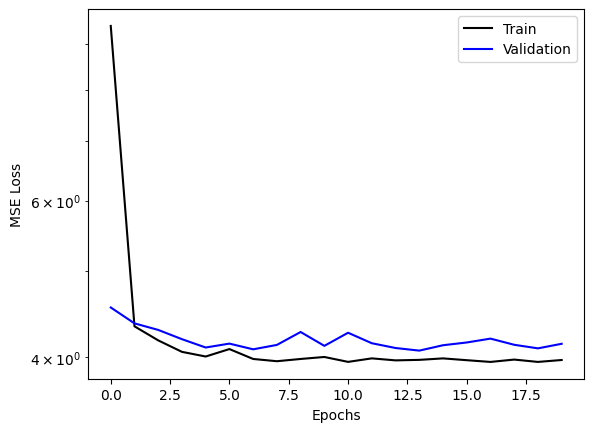

In [11]:

# Plot losses
plt.clf()
figure, ax = plt.subplots(1)
plt.semilogy(losses_train, color="k", label="Train")
plt.semilogy(losses_val, color="b", label="Validation")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()


### Test and plot results
Test on the unseen test dataset. 

In [12]:
X_test = torch.tensor(features_test, dtype=torch.float32).reshape((-1, 1))
Y_test = torch.tensor(targets_test, dtype=torch.float32).reshape((-1, 1))

Y_pred = nn_model(X_test)

RMSE = torch.sqrt(torch.mean((Y_test - Y_pred)**2))
RMSE

tensor(2.0715, grad_fn=<SqrtBackward0>)

<Figure size 640x480 with 0 Axes>

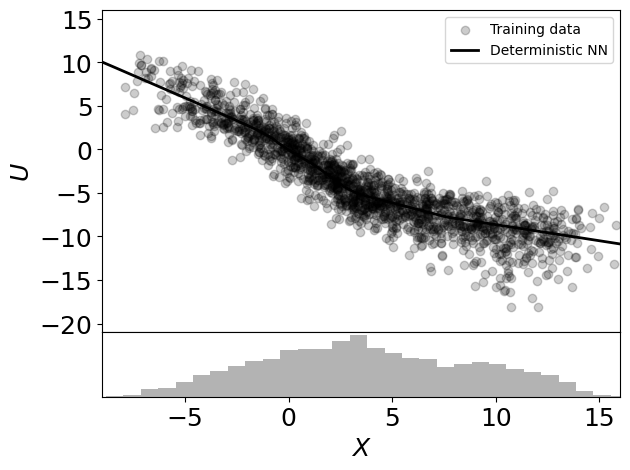

In [13]:

# Plot and save result
nn_model.eval()
plt.clf()

# Plot
Xmin=-9
Xmax=16
Ymin=-21
Ymax=16
figure, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
    gridspec_kw={'height_ratios': [5, 1], 'hspace':0})
X_domain = torch.linspace(Xmin, Xmax, 80).unsqueeze(-1)

# Plot raw data
plt.sca(ax1)
plt.scatter(X_torch.flatten()[::5], Y_torch.flatten()[::5], 
    color="k", alpha=0.2, label="Training data")
plt.axis(ymin=Ymin, ymax=Ymax, xmin=Xmin, xmax=Xmax)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel("$X$", fontsize=18)
plt.ylabel("$U$", fontsize=18)
plt.tight_layout()

# Deterministic prediction 
out = nn_model(X_domain).detach()
plt.plot(X_domain.squeeze(), out, color="k", linewidth=2, 
    label="Deterministic NN")
plt.legend()
# Add histogram
plt.sca(ax2)
plot_hist(X_torch.flatten()[::], ax2)
plt.axis(ymin=0, xmin=Xmin, xmax=Xmax)
plt.yticks([], fontsize=18)
plt.xticks(fontsize=18)
plt.xlabel("$X$", fontsize=18)
plt.tight_layout()



The neural network looks like it fits the data well, although it doesn't capture any uncertainty. Next, we will explore how well it works when we plug it back into the L96 model. 